# 🗑️ Transfer Learning - Klasifikasi Jenis Sampah

**Week 13 - Machine Learning**  
**D4 Robotics Engineering | Politeknik Negeri Batam**

---

## 📚 Metode yang Dipelajari
| Metode | Karakteristik | Dataset Size |
|---|---|---|
| Fixed Feature Extractor | Freeze semua pretrained layers | Kecil (<1K) |
| Fine-Tuning | Update semua layers | Sedang (1K-10K) |
| Pre-trained as Initialization | Starting point training | Besar (>10K) |

**Model:** MobileNetV2 (ringan, optimal untuk CPU)  
**Dataset:** TrashType Image Dataset (Kaggle) - 6 kelas sampah

## 1️⃣ Setup & Instalasi

In [3]:
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','tensorflow','numpy','matplotlib','seaborn','scikit-learn','pillow','-q'])


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['/bin/python3', '-m', 'pip', 'install', 'tensorflow', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'pillow', '-q'], returncode=0)

## 2️⃣ Import Library

In [4]:
import os, warnings, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU') or 'Tidak tersedia (CPU mode)'}")
print("✅ Library berhasil dimuat!")

/home/bes/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
2026-06-23 09:26:18.334930: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-23 09:26:18.451262: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-23 09:26:18.451336: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-23 09:26:18.453442: E external/local_xla/xla/stream_exe

TensorFlow: 2.15.0
GPU: Tidak tersedia (CPU mode)
✅ Library berhasil dimuat!


## 3️⃣ Konfigurasi & Load Dataset

In [5]:
# === KONFIGURASI ===
DATA_DIR   = "archive (4)/TrashType_Image_Dataset"
IMG_SIZE   = (128, 128)   # Lebih kecil agar cepat di CPU
BATCH_SIZE = 16           # Kecil untuk hemat RAM
EPOCHS_FEATURE = 10       # Fixed Feature Extractor
EPOCHS_FINETUNE = 10      # Fine-Tuning
EPOCHS_INIT = 10          # Pre-trained as Initialization
SEED = 42
CLASSES = ['cardboard','glass','metal','paper','plastic','trash']
NUM_CLASSES = len(CLASSES)

# === DATA AUGMENTATION ===
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED, classes=CLASSES)
val_gen = val_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED, classes=CLASSES, shuffle=False)

print(f"\nTotal training  : {train_gen.samples} gambar")
print(f"Total validasi  : {val_gen.samples} gambar")
print(f"Kelas           : {CLASSES}")

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.

Total training  : 2024 gambar
Total validasi  : 503 gambar
Kelas           : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 4️⃣ Visualisasi Sample Dataset

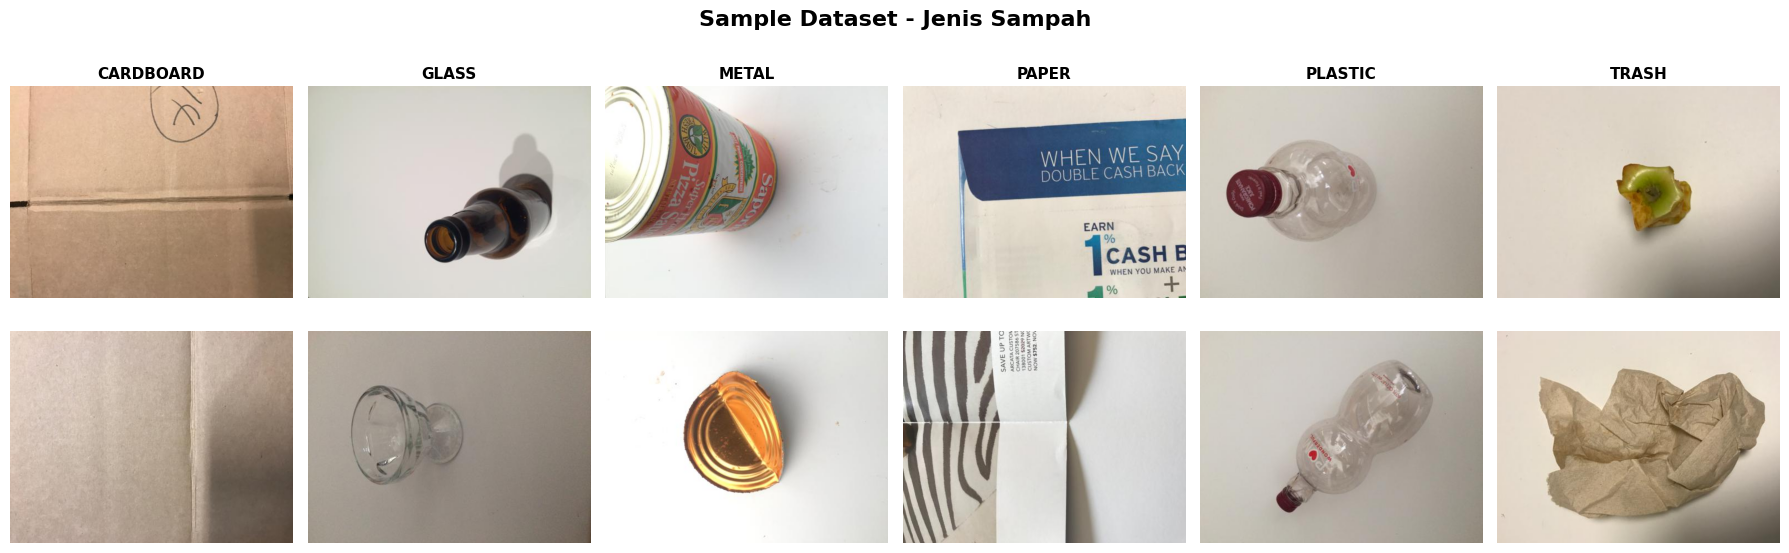

✅ Visualisasi dataset selesai!


In [6]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Sample Dataset - Jenis Sampah', fontsize=16, fontweight='bold')
for i, cls in enumerate(CLASSES):
    cls_dir = os.path.join(DATA_DIR, cls)
    img_file = sorted(os.listdir(cls_dir))[0]
    img = plt.imread(os.path.join(cls_dir, img_file))
    axes[0, i].imshow(img)
    axes[0, i].set_title(cls.upper(), fontsize=11, fontweight='bold')
    axes[0, i].axis('off')
    img2 = plt.imread(os.path.join(cls_dir, sorted(os.listdir(cls_dir))[1]))
    axes[1, i].imshow(img2)
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig('sample_dataset.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Visualisasi dataset selesai!")

### 📊 Distribusi Dataset

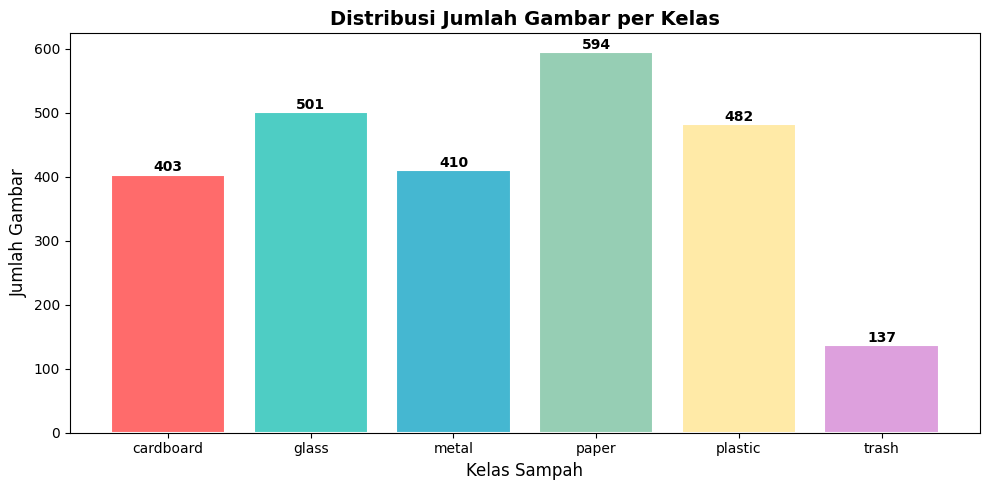

Total gambar: 2527


In [7]:
counts = [len(os.listdir(os.path.join(DATA_DIR,c))) for c in CLASSES]
colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(CLASSES, counts, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Distribusi Jumlah Gambar per Kelas', fontsize=14, fontweight='bold')
ax.set_xlabel('Kelas Sampah', fontsize=12)
ax.set_ylabel('Jumlah Gambar', fontsize=12)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_dataset.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Total gambar: {sum(counts)}")

---
## 🔒 METODE 1: Fixed Feature Extractor

> Semua layer pretrained di-**freeze** (dibekukan). Hanya layer classifier baru yang dilatih.  
> **Cocok untuk dataset kecil (<1K sampel)**

In [8]:
def build_fixed_feature_extractor():
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(*IMG_SIZE, 3))
    base.trainable = False  # FREEZE semua layer pretrained
    
    model = keras.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='FixedFeatureExtractor')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_ffe = build_fixed_feature_extractor()

# Hitung trainable params
trainable = sum([tf.size(w).numpy() for w in model_ffe.trainable_variables])
frozen    = sum([tf.size(w).numpy() for w in model_ffe.non_trainable_variables])
print(f"{'='*50}")
print(f"Model: Fixed Feature Extractor")
print(f"Base model (MobileNetV2) : FROZEN ❄️")
print(f"Parameter trainable      : {trainable:,}")
print(f"Parameter frozen         : {frozen:,}")
print(f"{'='*50}")

Model: Fixed Feature Extractor
Base model (MobileNetV2) : FROZEN ❄️
Parameter trainable      : 364,166
Parameter frozen         : 2,260,544


In [9]:
callbacks_ffe = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
]
print("🚀 Training Fixed Feature Extractor...")
history_ffe = model_ffe.fit(
    train_gen, epochs=EPOCHS_FEATURE,
    validation_data=val_gen,
    callbacks=callbacks_ffe, verbose=1
)
print("\n✅ Training selesai!")

🚀 Training Fixed Feature Extractor...
Epoch 1/10


2026-06-23 09:26:50.303079: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 25165824 exceeds 10% of free system memory.
2026-06-23 09:26:50.369045: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 25958400 exceeds 10% of free system memory.


  1/127 [..............................] - ETA: 23:34 - loss: 2.6376 - accuracy: 0.1875

2026-06-23 09:26:50.947540: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 25165824 exceeds 10% of free system memory.
2026-06-23 09:26:50.998474: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 25958400 exceeds 10% of free system memory.


  2/127 [..............................] - ETA: 1:11 - loss: 2.5191 - accuracy: 0.1875 

2026-06-23 09:26:51.433276: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 25165824 exceeds 10% of free system memory.


127/127 [==============================] - 110s 783ms/step - loss: 1.4109 - accuracy: 0.5138 - val_loss: 0.7934 - val_accuracy: 0.6998 - lr: 0.0010
Epoch 2/10
127/127 [==============================] - 90s 709ms/step - loss: 0.9707 - accuracy: 0.6546 - val_loss: 0.7307 - val_accuracy: 0.7336 - lr: 0.0010
Epoch 3/10
127/127 [==============================] - 166s 1s/step - loss: 0.8649 - accuracy: 0.6818 - val_loss: 0.6457 - val_accuracy: 0.7853 - lr: 0.0010
Epoch 4/10
127/127 [==============================] - 122s 958ms/step - loss: 0.7967 - accuracy: 0.7288 - val_loss: 0.6783 - val_accuracy: 0.7734 - lr: 0.0010
Epoch 5/10
127/127 [==============================] - 148s 1s/step - loss: 0.7248 - accuracy: 0.7263 - val_loss: 0.6953 - val_accuracy: 0.7714 - lr: 0.0010
Epoch 6/10
127/127 [==============================] - ETA: 0s - loss: 0.6829 - accuracy: 0.7520
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
127/127 [==============================] - 77s 601m

---
## 🔓 METODE 2: Fine-Tuning

> Layer pretrained **tidak dibekukan** - semua layer ikut dilatih ulang dengan learning rate rendah.  
> **Cocok untuk dataset sedang (1K-10K sampel)**

In [10]:
def build_fine_tuning():
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(*IMG_SIZE, 3))
    # Fine-tuning: unfreeze top 30 layers
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False
    
    model = keras.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='FineTuning')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # LR kecil!
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_ft = build_fine_tuning()
trainable = sum([tf.size(w).numpy() for w in model_ft.trainable_variables])
frozen    = sum([tf.size(w).numpy() for w in model_ft.non_trainable_variables])
print(f"{'='*50}")
print(f"Model: Fine-Tuning")
print(f"30 layer terakhir base model : UNFROZEN 🔥")
print(f"Parameter trainable          : {trainable:,}")
print(f"Parameter frozen             : {frozen:,}")
print(f"{'='*50}")

Model: Fine-Tuning
30 layer terakhir base model : UNFROZEN 🔥
Parameter trainable          : 1,890,566
Parameter frozen             : 734,144


In [11]:
callbacks_ft = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
]
print("🚀 Training Fine-Tuning...")
train_gen.reset(); val_gen.reset()
history_ft = model_ft.fit(
    train_gen, epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=callbacks_ft, verbose=1
)
print("\n✅ Training selesai!")

🚀 Training Fine-Tuning...
Epoch 1/10
127/127 [==============================] - 104s 640ms/step - loss: 1.8788 - accuracy: 0.3720 - val_loss: 1.0856 - val_accuracy: 0.5765 - lr: 1.0000e-04
Epoch 2/10
127/127 [==============================] - 128s 1s/step - loss: 1.2506 - accuracy: 0.5425 - val_loss: 0.9787 - val_accuracy: 0.6223 - lr: 1.0000e-04
Epoch 3/10
127/127 [==============================] - 146s 1s/step - loss: 1.0318 - accuracy: 0.6398 - val_loss: 0.9570 - val_accuracy: 0.6660 - lr: 1.0000e-04
Epoch 4/10
127/127 [==============================] - 142s 1s/step - loss: 0.8825 - accuracy: 0.6887 - val_loss: 0.9270 - val_accuracy: 0.6759 - lr: 1.0000e-04
Epoch 5/10
127/127 [==============================] - 212s 2s/step - loss: 0.8130 - accuracy: 0.7120 - val_loss: 0.8145 - val_accuracy: 0.7416 - lr: 1.0000e-04
Epoch 6/10
127/127 [==============================] - 184s 1s/step - loss: 0.7197 - accuracy: 0.7475 - val_loss: 0.8013 - val_accuracy: 0.7256 - lr: 1.0000e-04
Epoch 7/10


---
## 🏁 METODE 3: Pre-trained as Initialization

> Model pretrained digunakan sebagai **titik awal** training. Semua weight dilatih dari bobot ImageNet.  
> **Cocok untuk dataset besar (>10K sampel)**

In [12]:
def build_pretrained_init():
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(*IMG_SIZE, 3))
    # Pre-trained as Initialization: semua weight mulai dari ImageNet
    # kemudian seluruhnya dilatih (berbeda dengan fine-tuning yang freeze sebagian)
    base.trainable = True  # Semua layer trainable (starting from pretrained weights)
    
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)  # training=False agar BatchNorm stabil
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs, name='PretrainedInit')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-5),  # LR sangat kecil krn semua layer trainable
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_pi = build_pretrained_init()
trainable = sum([tf.size(w).numpy() for w in model_pi.trainable_variables])
frozen    = sum([tf.size(w).numpy() for w in model_pi.non_trainable_variables])
print(f"{'='*55}")
print(f"Model: Pre-trained as Initialization")
print(f"Semua layer MobileNetV2     : TRAINABLE 🔥🔥")
print(f"Perbedaan dgn Fine-Tuning   : Tidak ada layer yang difreeze")
print(f"Optimizer                   : Adam (LR=5e-5, sangat konservatif)")
print(f"Parameter trainable         : {trainable:,}")
print(f"Parameter frozen (BN only)  : {frozen:,}")
print(f"{'='*55}")

Model: Pre-trained as Initialization
Semua layer MobileNetV2     : TRAINABLE 🔥🔥
Perbedaan dgn Fine-Tuning   : Tidak ada layer yang difreeze
Optimizer                   : Adam (LR=5e-5, sangat konservatif)
Parameter trainable         : 3,015,174
Parameter frozen (BN only)  : 36,672


In [13]:
callbacks_pi = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7, verbose=1),
]
print("🚀 Training Pre-trained as Initialization...")
print("   Catatan: Semua layer dilatih dari bobot ImageNet (bukan dari awal)")
train_gen.reset(); val_gen.reset()
history_pi = model_pi.fit(
    train_gen, epochs=EPOCHS_INIT,
    validation_data=val_gen,
    callbacks=callbacks_pi, verbose=1
)
print(f"\n✅ Training selesai!")
print(f"   Val Accuracy terbaik: {max(history_pi.history['val_accuracy'])*100:.2f}%")

🚀 Training Pre-trained as Initialization...
   Catatan: Semua layer dilatih dari bobot ImageNet (bukan dari awal)


Epoch 1/10
127/127 [==============================] - 503s 3s/step - loss: 1.7001 - accuracy: 0.3370 - val_loss: 1.4604 - val_accuracy: 0.4751 - lr: 5.0000e-05
Epoch 2/10
127/127 [==============================] - 369s 3s/step - loss: 1.2998 - accuracy: 0.5069 - val_loss: 1.6611 - val_accuracy: 0.3837 - lr: 5.0000e-05
Epoch 3/10
127/127 [==============================] - 179s 1s/step - loss: 1.0597 - accuracy: 0.5934 - val_loss: 0.8279 - val_accuracy: 0.6958 - lr: 5.0000e-05
Epoch 4/10
127/127 [==============================] - 144s 1s/step - loss: 0.9456 - accuracy: 0.6359 - val_loss: 0.8466 - val_accuracy: 0.6779 - lr: 5.0000e-05
Epoch 5/10
127/127 [==============================] - 145s 1s/step - loss: 0.8347 - accuracy: 0.6952 - val_loss: 0.8388 - val_accuracy: 0.7217 - lr: 5.0000e-05
Epoch 6/10
127/127 [==============================] - ETA: 0s - loss: 0.7274 - accuracy: 0.7253
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
127/127 [===================

---
## 📈 5️⃣ Visualisasi Training History

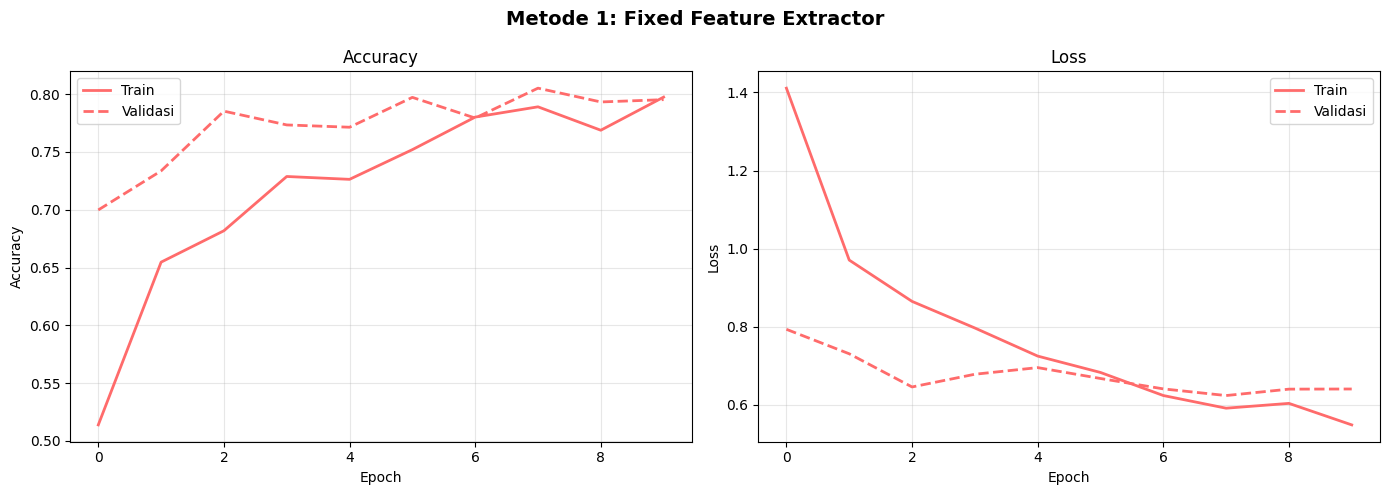

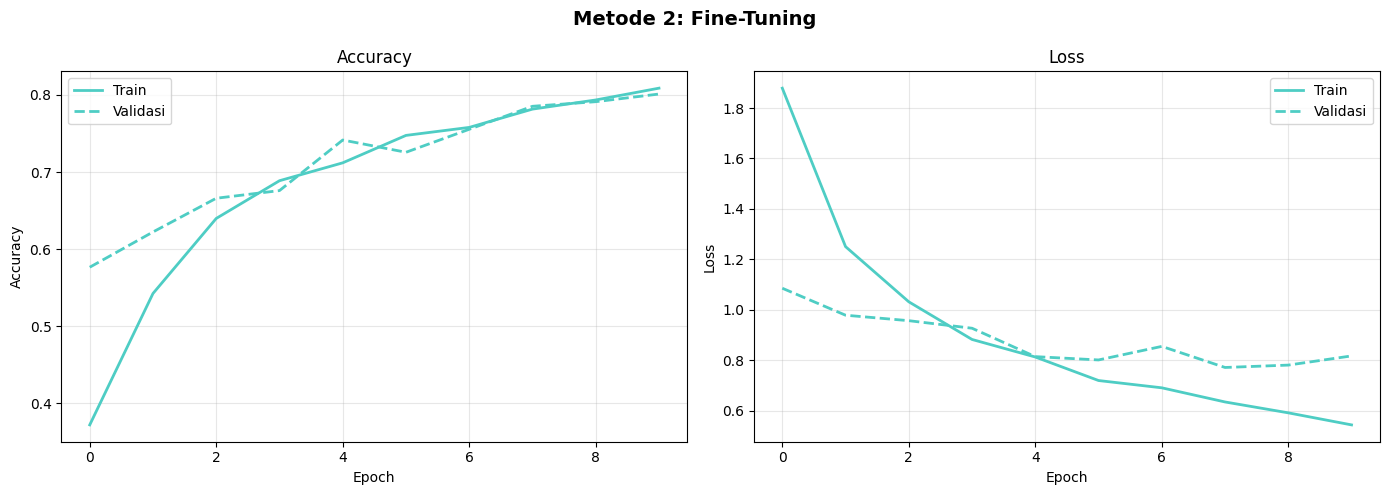

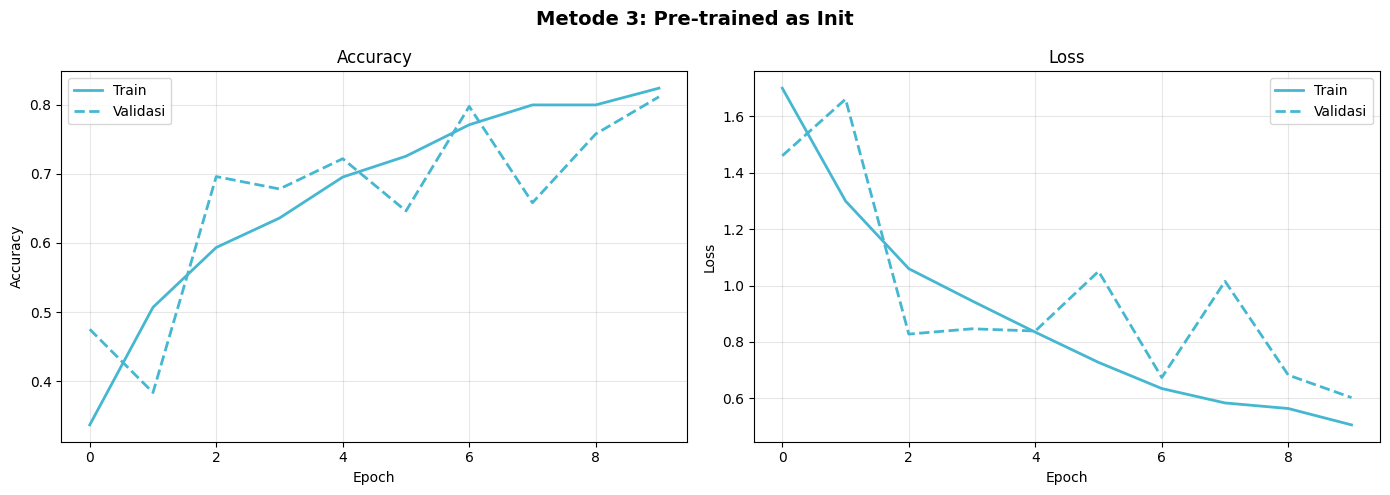

In [14]:
def plot_history(history, title, color):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    # Accuracy
    ax1.plot(history.history['accuracy'], color=color, linewidth=2, label='Train')
    ax1.plot(history.history['val_accuracy'], color=color, linewidth=2,
             linestyle='--', label='Validasi')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)
    # Loss
    ax2.plot(history.history['loss'], color=color, linewidth=2, label='Train')
    ax2.plot(history.history['val_loss'], color=color, linewidth=2,
             linestyle='--', label='Validasi')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    safe = title.replace(' ','_').replace(':','')
    plt.savefig(f'history_{safe}.png', dpi=100, bbox_inches='tight')
    plt.show()

plot_history(history_ffe, 'Metode 1: Fixed Feature Extractor', '#FF6B6B')
plot_history(history_ft,  'Metode 2: Fine-Tuning',             '#4ECDC4')
plot_history(history_pi,  'Metode 3: Pre-trained as Init',     '#45B7D1')

## 🎯 6️⃣ Evaluasi & Perbandingan Model

In [15]:
def evaluate_model(model, gen, name):
    gen.reset()
    loss, acc = model.evaluate(gen, verbose=0)
    gen.reset()
    y_pred = np.argmax(model.predict(gen, verbose=0), axis=1)
    y_true = gen.classes
    return {'name': name, 'loss': loss, 'accuracy': acc,
            'y_pred': y_pred, 'y_true': y_true}

print("Mengevaluasi semua model...")
res_ffe = evaluate_model(model_ffe, val_gen, 'Fixed Feature Extractor')
res_ft  = evaluate_model(model_ft,  val_gen, 'Fine-Tuning')
res_pi  = evaluate_model(model_pi,  val_gen, 'Pre-trained Init')

print("\n" + "="*60)
print(f"{'Model':<30} {'Loss':>8} {'Accuracy':>10}")
print("="*60)
for r in [res_ffe, res_ft, res_pi]:
    print(f"{r['name']:<30} {r['loss']:>8.4f} {r['accuracy']*100:>9.2f}%")
print("="*60)

Mengevaluasi semua model...

Model                              Loss   Accuracy
Fixed Feature Extractor          0.6405     79.52%
Fine-Tuning                      0.8173     80.12%
Pre-trained Init                 0.6026     81.11%


In [16]:
for r in [res_ffe, res_ft, res_pi]:
    print(f"\n{'='*60}")
    print(f"📊 {r['name']}")
    print('='*60)
    print(classification_report(r['y_true'], r['y_pred'], target_names=CLASSES))


📊 Fixed Feature Extractor
              precision    recall  f1-score   support

   cardboard       0.84      0.94      0.89        80
       glass       0.81      0.87      0.84       100
       metal       0.78      0.85      0.81        82
       paper       0.80      0.86      0.83       118
     plastic       0.82      0.56      0.67        96
       trash       0.52      0.48      0.50        27

    accuracy                           0.80       503
   macro avg       0.76      0.76      0.76       503
weighted avg       0.79      0.80      0.79       503


📊 Fine-Tuning
              precision    recall  f1-score   support

   cardboard       0.99      0.82      0.90        80
       glass       0.78      0.88      0.83       100
       metal       0.88      0.80      0.84        82
       paper       0.69      0.96      0.80       118
     plastic       0.85      0.65      0.73        96
       trash       0.67      0.30      0.41        27

    accuracy                       

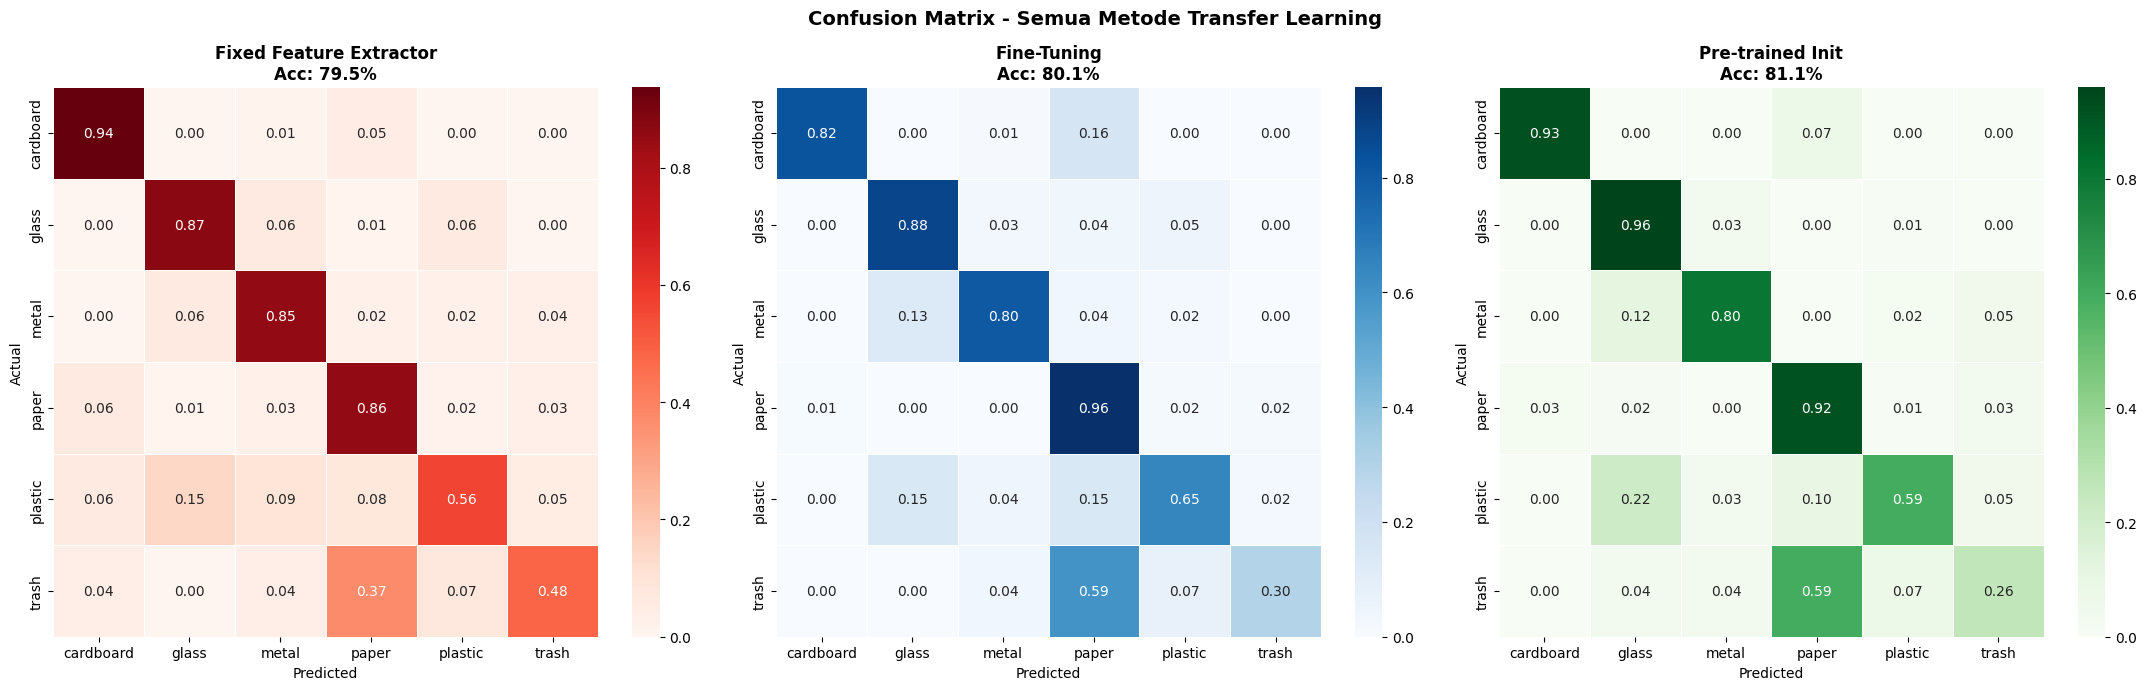

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
results = [res_ffe, res_ft, res_pi]
titles  = ['Fixed Feature Extractor','Fine-Tuning','Pre-trained Init']
cmaps   = ['Reds','Blues','Greens']

for ax, res, title, cmap in zip(axes, results, titles, cmaps):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    cm_norm = cm.astype(float)/cm.sum(axis=1)[:,np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
                linewidths=0.5)
    ax.set_title(f'{title}\nAcc: {res["accuracy"]*100:.1f}%', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix - Semua Metode Transfer Learning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

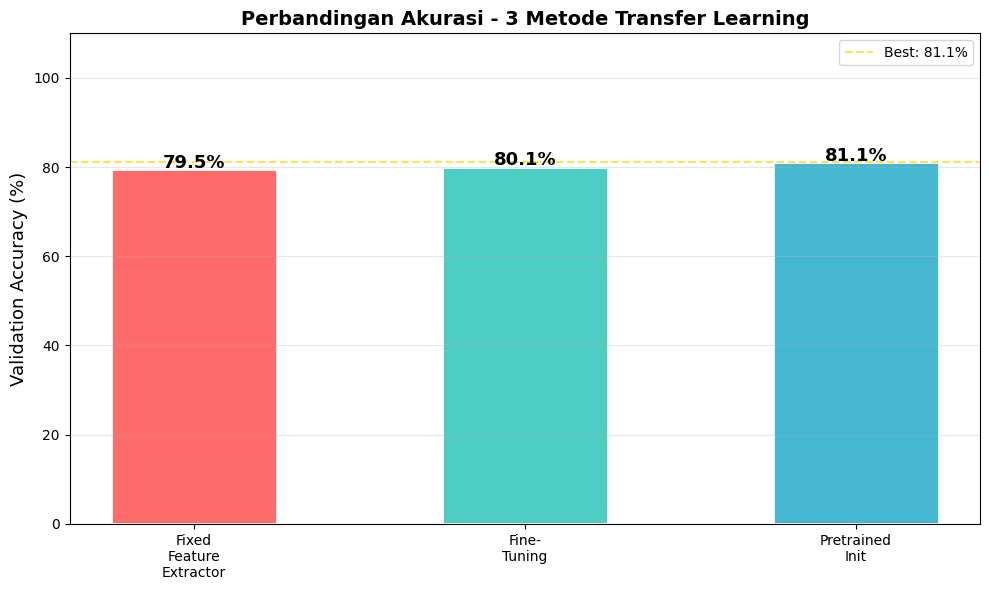

🏆 Model terbaik: Pretrained Init dengan akurasi 81.11%


In [18]:
names = ['Fixed\nFeature\nExtractor','Fine-\nTuning','Pretrained\nInit']
accs  = [r['accuracy']*100 for r in [res_ffe, res_ft, res_pi]]
colors_bar = ['#FF6B6B','#4ECDC4','#45B7D1']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(names, accs, color=colors_bar, edgecolor='white', linewidth=2, width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{acc:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_ylabel('Validation Accuracy (%)', fontsize=13)
ax.set_title('Perbandingan Akurasi - 3 Metode Transfer Learning', fontsize=14, fontweight='bold')
ax.axhline(y=max(accs), color='gold', linestyle='--', alpha=0.7, label=f'Best: {max(accs):.1f}%')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=100, bbox_inches='tight')
plt.show()
best = names[accs.index(max(accs))].replace('\n',' ')
print(f"🏆 Model terbaik: {best} dengan akurasi {max(accs):.2f}%")

## 🔮 7️⃣ Prediksi Gambar Baru

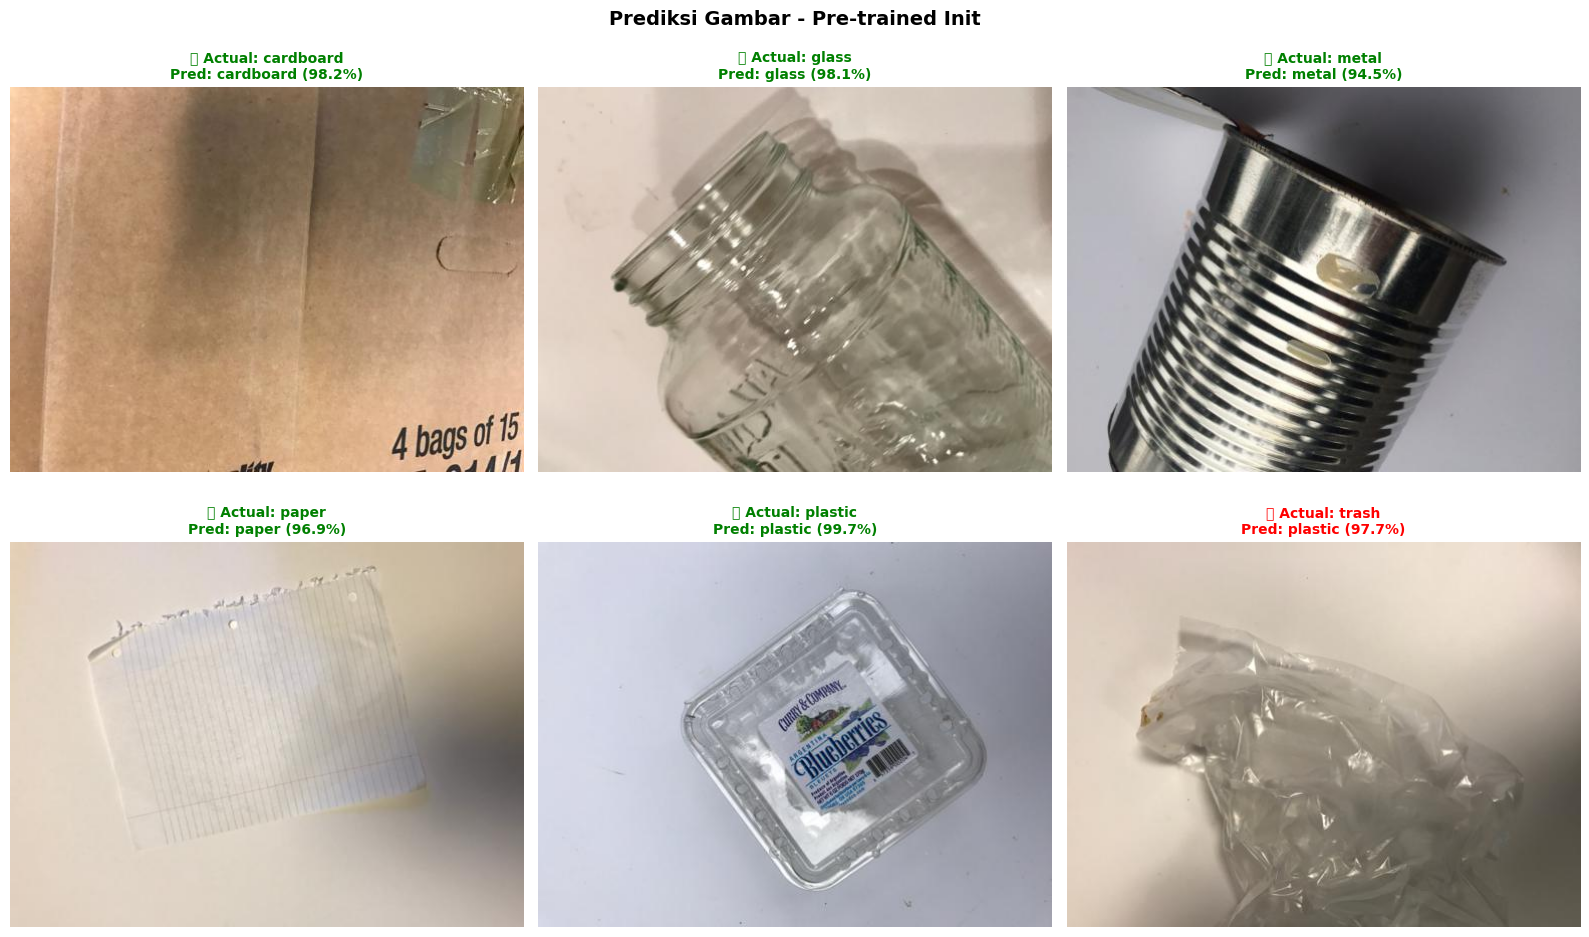

In [19]:
import random
from PIL import Image

def predict_image(model, img_path, model_name="Model"):
    img = Image.open(img_path).resize(IMG_SIZE)
    arr = np.array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    preds = model.predict(arr, verbose=0)[0]
    idx = np.argmax(preds)
    return CLASSES[idx], preds[idx]*100, preds

# Ambil gambar random dari dataset
test_imgs, test_labels = [], []
for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    files = os.listdir(cls_dir)
    test_imgs.append(os.path.join(cls_dir, random.choice(files)))
    test_labels.append(cls)

# Tampilkan prediksi best model (gunakan yang akurasi terbaik)
best_model = [model_ffe, model_ft, model_pi][accs.index(max(accs))]
best_name  = ['Fixed Feature Extractor','Fine-Tuning','Pre-trained Init'][accs.index(max(accs))]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle(f'Prediksi Gambar - {best_name}', fontsize=14, fontweight='bold')

for i, (img_path, true_label) in enumerate(zip(test_imgs, test_labels)):
    pred_class, conf, _ = predict_image(best_model, img_path, best_name)
    img = plt.imread(img_path)
    axes[i].imshow(img)
    color = 'green' if pred_class == true_label else 'red'
    icon  = '✅' if pred_class == true_label else '❌'
    axes[i].set_title(
        f'{icon} Actual: {true_label}\nPred: {pred_class} ({conf:.1f}%)',
        color=color, fontweight='bold', fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('prediksi_gambar.png', dpi=100, bbox_inches='tight')
plt.show()

## 💾 8️⃣ Simpan Model Terbaik

In [20]:
best_idx   = accs.index(max(accs))
best_model_obj  = [model_ffe, model_ft, model_pi][best_idx]
best_model_name = ['fixed_feature_extractor','fine_tuning','pretrained_init'][best_idx]
save_path = f'best_model_{best_model_name}.keras'
best_model_obj.save(save_path)
print(f"✅ Model terbaik disimpan: {save_path}")
print(f"   Metode : {['Fixed Feature Extractor','Fine-Tuning','Pre-trained Init'][best_idx]}")
print(f"   Akurasi: {max(accs):.2f}%")

✅ Model terbaik disimpan: best_model_pretrained_init.keras
   Metode : Pre-trained Init
   Akurasi: 81.11%


---
## 📝 9️⃣ Kesimpulan

In [21]:
print("="*65)
print("  KESIMPULAN - Transfer Learning Klasifikasi Sampah")
print("="*65)
methods = ['Fixed Feature Extractor','Fine-Tuning','Pre-trained Init']
for m, acc in zip(methods, accs):
    bar = '█' * int(acc/5)
    print(f"  {m:<28} {acc:5.1f}% {bar}")
print("="*65)
print(f"\n🏆 Model terbaik : {methods[accs.index(max(accs))]}")
print(f"   Akurasi       : {max(accs):.2f}%")
print(f"   Dataset       : TrashType Image Dataset (6 kelas)")
print(f"   Base Model    : MobileNetV2 (ImageNet weights)")
print("\n📌 Penjelasan Metode:")
print("  1. Fixed Feature Extractor → Cepat, hemat komputasi")
print("  2. Fine-Tuning → Akurasi lebih tinggi, adaptif ke dataset")
print("  3. Pre-trained Init → Fleksibel, tapi butuh data lebih banyak")
print("\n✅ Notebook selesai!")

  KESIMPULAN - Transfer Learning Klasifikasi Sampah
  Fixed Feature Extractor       79.5% ███████████████
  Fine-Tuning                   80.1% ████████████████
  Pre-trained Init              81.1% ████████████████

🏆 Model terbaik : Pre-trained Init
   Akurasi       : 81.11%
   Dataset       : TrashType Image Dataset (6 kelas)
   Base Model    : MobileNetV2 (ImageNet weights)

📌 Penjelasan Metode:
  1. Fixed Feature Extractor → Cepat, hemat komputasi
  2. Fine-Tuning → Akurasi lebih tinggi, adaptif ke dataset
  3. Pre-trained Init → Fleksibel, tapi butuh data lebih banyak

✅ Notebook selesai!
